#### Libraries + Configuration

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.font_manager as fm
from scipy import stats
from itertools import combinations
import matplotlib
from matplotlib import rcParams

# ── Output directory
OUTPUT_DIR = Path().resolve() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Font settings
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── Global style
rcParams.update({
    "figure.facecolor" : "#1B2A4A",   # Navy background
    "axes.facecolor"   : "#243558",   # Plot area
    "axes.edgecolor"   : "#4A6080",
    "axes.labelcolor"  : "#FFFFFF",   # White
    "axes.titlecolor"  : "#FFFFFF",   # White
    "xtick.color"      : "#FFFFFF",   # White
    "ytick.color"      : "#FFFFFF",   # White
    "text.color"       : "#FFFFFF",   # White
    "grid.color"       : "#4A6080",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "font.size"        : 10,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
    "legend.framealpha": 0.6,
    "legend.edgecolor" : "#4A6080",
    "legend.facecolor" : "#1B2A4A",
})

# ── Colors
C_GOOD, C_BAD = "#1D9E75", "#C44E52"
C_BEFORE, C_DURING, C_AFTER = "#4C72B0", "#888780", "#C44E52"

# Keep original Korean category values for data processing
TIMING_COLORS = {
    "장전": C_BEFORE,
    "장중": C_DURING,
    "장후": C_AFTER
}

# English labels for visualization
TIMING_LABELS = {
    "장전": "Pre-market",
    "장중": "Intraday",
    "장후": "After-hours"
}

NEWS_LABELS = {
    "호재": "Good News",
    "악재": "Bad News"
}

#### Data Preprocessing

In [2]:
DATA_DIR = Path("../data_collection")

raw_fin  = pd.read_csv(DATA_DIR / "dart_earnings_financials_2019_2026.csv", dtype=str)
raw_ctrl = pd.read_csv(DATA_DIR / "dart_financial_controls_2019_2025.csv")
raw_comp = pd.read_csv(DATA_DIR / "company_krx_fdr_controls_2019_2026.csv")

print(f"Disclosure data: {len(raw_fin):,} rows")

Disclosure data: 16,218 rows


In [3]:
# Filtering
remove = raw_fin["report_nm"].str.contains(
    "전망|기재정정|첨부정정|첨부추가|월별|monthly", na=False, regex=True
)
fin = raw_fin[~remove].copy()
fin["year"] = fin["rcept_dt"].str[:4].astype(int)
fin = fin[fin["year"] <= 2025].copy()

# Remove duplicates, prioritizing consolidated disclosures
fin["is_consolidated"] = fin["report_nm"].str.contains("연결", na=False)
fin = fin.sort_values(
    ["stock_code", "rcept_dt", "is_consolidated", "rcept_no"],
    ascending=[True, True, False, True]
)
fin = fin.drop_duplicates(subset=["stock_code", "rcept_dt"], keep="first")

# Classify disclosure timing
t = fin["rcept_time"].str.split(":", expand=True)
fin["_h"] = pd.to_numeric(t[0], errors="coerce")
fin["_m"] = pd.to_numeric(t[1], errors="coerce")
fin["timing"] = "Intraday"
fin.loc[fin["_h"] < 9, "timing"] = "Pre-market"
fin.loc[(fin["_h"] > 15) | ((fin["_h"] == 15) & (fin["_m"] > 30)), "timing"] = "After-hours"
fin.loc[fin["_h"].isna(), "timing"] = None
fin.drop(columns=["_h", "_m"], inplace=True)
fin["rcept_dt_dt"] = pd.to_datetime(fin["rcept_dt"], format="%Y%m%d")
fin["weekday"] = fin["rcept_dt_dt"].dt.dayofweek

# Classify good and bad news
fin["oi_won"] = pd.to_numeric(fin["operating_income_won"], errors="coerce")
fin = fin.sort_values(["stock_code", "rcept_dt_dt"])
fin["prev_oi"] = fin.groupby("stock_code")["oi_won"].shift(1)
fin["oi_chg_pct"] = np.where(
    fin["prev_oi"].notna() & (fin["prev_oi"] != 0),
    (fin["oi_won"] - fin["prev_oi"]) / fin["prev_oi"].abs(),
    np.nan
)
fin["news"] = np.select(
    [fin["oi_chg_pct"] > 0.10, fin["oi_chg_pct"] < -0.10,
     fin["oi_chg_pct"].between(-0.10, 0.10, inclusive="both")],
    ["Good News", "Bad News", "Neutral"], default="Missing"
)

df = fin.copy()
df_hb = df[df["news"].isin(["Good News", "Bad News"]) & df["timing"].notna()].copy()

print(f"Final sample: {len(df):,} observations")
print(f"Good News: {df['news'].eq('Good News').sum():,}  Bad News: {df['news'].eq('Bad News').sum():,}")
print(f"Timing: {df['timing'].value_counts().to_dict()}")

Final sample: 12,310 observations
Good News: 4,534  Bad News: 4,030
Timing: {'Intraday': 6362, 'After-hours': 5118, 'Pre-market': 811}


### 6. Comparison of Disclosure Timing Patterns by Market Capitalization Group


=== Share of After-Hours Bad-News Disclosures by Market Capitalization Group ===
size_group  total  bad_total  bad_after  bad_after_pct  after_pct  bad_ratio_pct  kosdaq_ratio_pct  mean_log_marcap
     Small   2857       1364        707           51.8       45.7           47.7              61.1            25.58
       Mid   2845       1334        639           47.9       43.2           46.9              36.8            27.38
     Large   2849       1326        541           40.8       38.2           46.5              11.1            29.86

=== Chi-Square Test: Market Capitalization Group × After-Hours Bad-News Disclosure ===
after_dummy    0    1
size_group           
Small        657  707
Mid          695  639
Large        785  541
chi2 = 33.681
p-value = 0.0000

=== Logistic Regression: Probability of After-Hours Bad-News Disclosure by Market Capitalization Group ===
                           Logit Regression Results                           
Dep. Variable:            after_dummy 

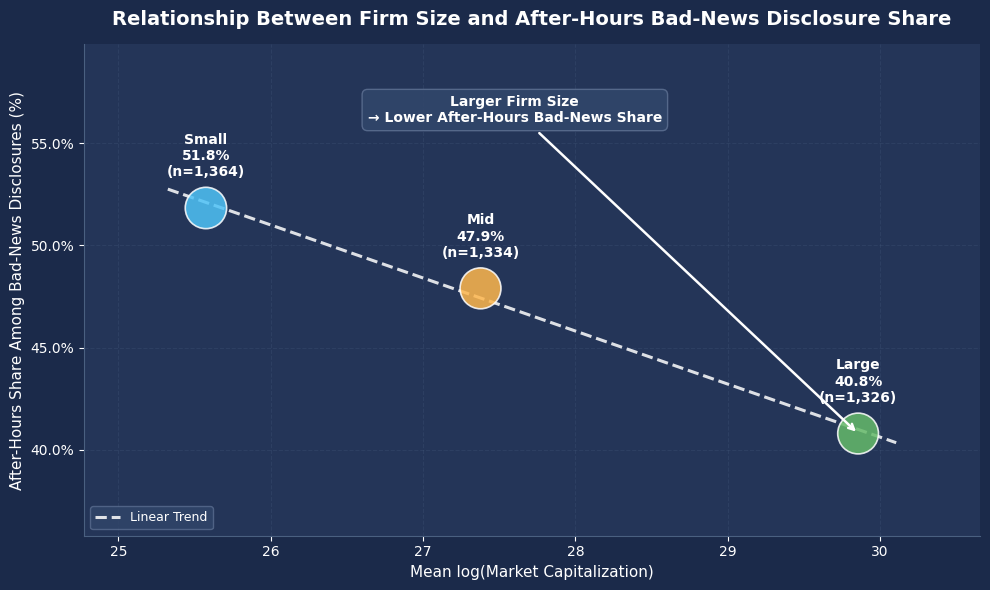

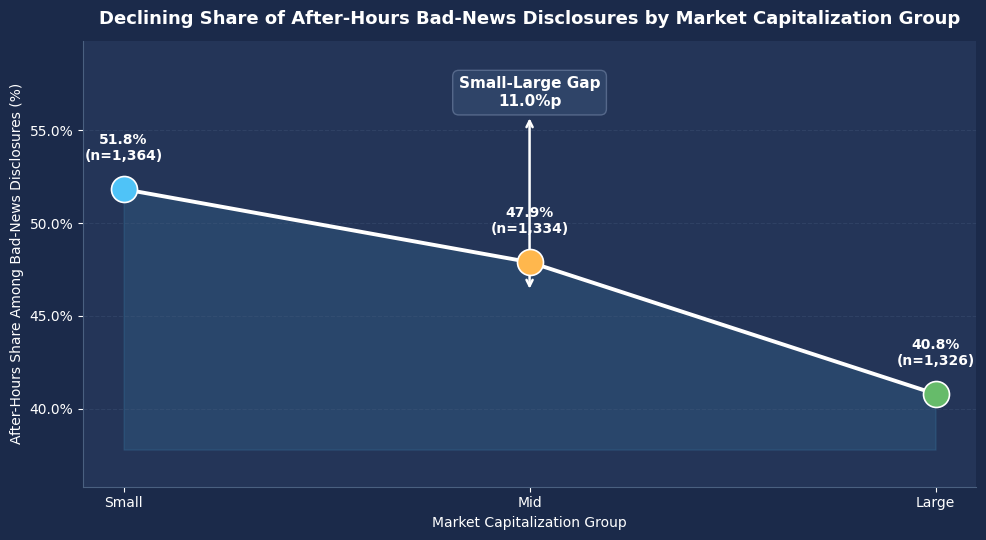

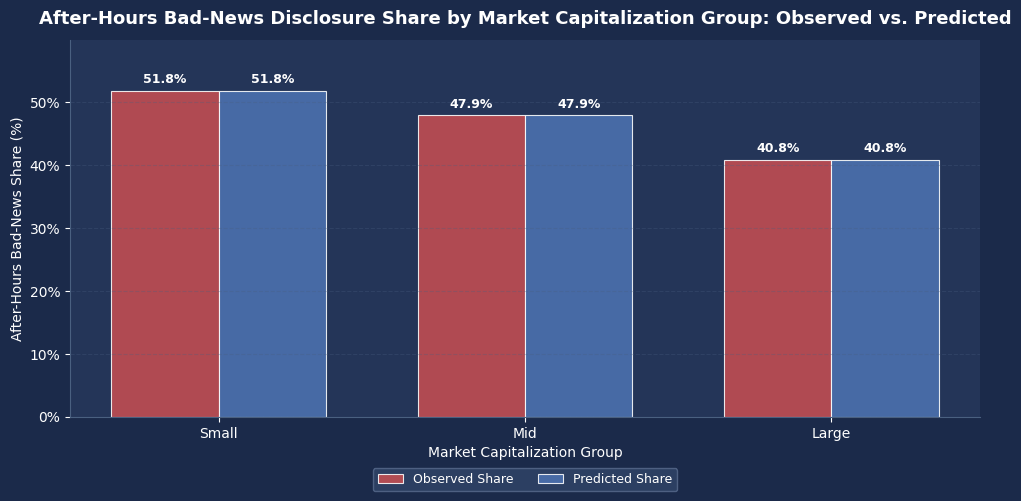


Files saved:
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\06_size_group_bubble_trend.png
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\06_size_group_gap_focus.png
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\06_size_group_observed_predicted.png


In [4]:
# ============================================================
# 6. Comparison of Disclosure Timing Patterns by Market Capitalization Group
# - Classify firms into Small / Mid / Large terciles based on log_marcap
# - Compare the share of after-hours bad-news disclosures across size groups
# - Bubble + Trend Line visualization
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import statsmodels.formula.api as smf

BG_COLOR = "#1B2A4A"


# ------------------------------------------------------------
# 1. Construct Analysis Dataset
# ------------------------------------------------------------

size_df = df_hb.copy()

size_df = size_df[
    size_df["news"].isin(["Good News", "Bad News"])
    & size_df["timing"].isin(
        ["Pre-market", "Intraday", "After-hours"]
    )
].copy()

size_df["stock_code"] = (
    size_df["stock_code"]
    .astype(str)
    .str.zfill(6)
)


# ------------------------------------------------------------
# 2. Merge Market Capitalization and KOSDAQ Variables
# ------------------------------------------------------------

raw_comp2 = raw_comp.copy()

raw_comp2["stock_code"] = (
    raw_comp2["stock_code"]
    .astype(str)
    .str.zfill(6)
)


if "is_kosdaq" not in raw_comp2.columns:

    raw_comp2["is_kosdaq"] = (
        raw_comp2["market"]
        .astype(str)
        .str.upper()
        .str.contains(
            "KOSDAQ|코스닥",
            na=False
        )
        .astype(int)
    )


if "log_marcap" not in raw_comp2.columns:

    raw_comp2["marcap"] = pd.to_numeric(
        raw_comp2["marcap"],
        errors="coerce"
    )

    raw_comp2["log_marcap"] = np.log(
        raw_comp2["marcap"]
    )


size_df = size_df.merge(
    raw_comp2[
        [
            "stock_code",
            "market",
            "is_kosdaq",
            "log_marcap"
        ]
    ].drop_duplicates(
        "stock_code"
    ),
    on="stock_code",
    how="left"
)


size_df["log_marcap"] = pd.to_numeric(
    size_df["log_marcap"],
    errors="coerce"
)

size_df = size_df.dropna(
    subset=["log_marcap"]
).copy()


# ------------------------------------------------------------
# 3. Create Market Capitalization Terciles
# ------------------------------------------------------------

size_df["size_group"] = pd.qcut(
    size_df["log_marcap"],
    q=3,
    labels=[
        "Small",
        "Mid",
        "Large"
    ]
)


size_df["size_group"] = pd.Categorical(
    size_df["size_group"],
    categories=[
        "Small",
        "Mid",
        "Large"
    ],
    ordered=True
)


size_df["after_dummy"] = (
    size_df["timing"] == "After-hours"
).astype(int)


size_df["bad_dummy"] = (
    size_df["news"] == "Bad News"
).astype(int)


size_df["bad_after"] = (
    (size_df["bad_dummy"] == 1)
    & (size_df["after_dummy"] == 1)
).astype(int)


# ------------------------------------------------------------
# 4. Descriptive Statistics by Market Capitalization Group
# ------------------------------------------------------------

size_summary = (
    size_df
    .groupby(
        "size_group",
        observed=False
    )
    .agg(
        total=("news", "size"),
        bad_total=("bad_dummy", "sum"),
        after_total=("after_dummy", "sum"),
        bad_after=("bad_after", "sum"),
        mean_log_marcap=("log_marcap", "mean"),
        kosdaq_ratio=("is_kosdaq", "mean")
    )
    .reset_index()
)


size_summary["after_pct"] = (
    size_summary["after_total"]
    / size_summary["total"]
    * 100
)


size_summary["bad_ratio_pct"] = (
    size_summary["bad_total"]
    / size_summary["total"]
    * 100
)


size_summary["bad_after_pct"] = (
    size_summary["bad_after"]
    / size_summary["bad_total"]
    * 100
)


size_summary["kosdaq_ratio_pct"] = (
    size_summary["kosdaq_ratio"]
    * 100
)


print(
    "\n=== Share of After-Hours Bad-News Disclosures "
    "by Market Capitalization Group ==="
)


print(
    size_summary[
        [
            "size_group",
            "total",
            "bad_total",
            "bad_after",
            "bad_after_pct",
            "after_pct",
            "bad_ratio_pct",
            "kosdaq_ratio_pct",
            "mean_log_marcap"
        ]
    ]
    .round({
        "bad_after_pct": 1,
        "after_pct": 1,
        "bad_ratio_pct": 1,
        "kosdaq_ratio_pct": 1,
        "mean_log_marcap": 2
    })
    .to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 5. Test for Differences Across Size Groups
#    within the Bad-News Sample
# ------------------------------------------------------------

bad_only = size_df[
    size_df["bad_dummy"] == 1
].copy()


contingency = pd.crosstab(
    bad_only["size_group"],
    bad_only["after_dummy"]
)


chi2, p_chi, dof, expected = (
    stats.chi2_contingency(
        contingency
    )
)


print(
    "\n=== Chi-Square Test: "
    "Market Capitalization Group × "
    "After-Hours Bad-News Disclosure ==="
)

print(
    contingency
)

print(
    f"chi2 = {chi2:.3f}"
)

print(
    f"p-value = {p_chi:.4f}"
)


# ------------------------------------------------------------
# 6. Logistic Regression:
#    Probability of Choosing After-Hours Disclosure for Bad News
# ------------------------------------------------------------

bad_only["size_group"] = pd.Categorical(
    bad_only["size_group"],
    categories=[
        "Small",
        "Mid",
        "Large"
    ],
    ordered=True
)


logit_size = smf.logit(
    "after_dummy ~ C(size_group) + is_kosdaq + log_marcap",
    data=bad_only
).fit(
    disp=False
)


print(
    "\n=== Logistic Regression: "
    "Probability of After-Hours Bad-News Disclosure "
    "by Market Capitalization Group ==="
)

print(
    logit_size.summary()
)


# ------------------------------------------------------------
# 7. Calculate Predicted Probabilities
# ------------------------------------------------------------

pred_df = bad_only.copy()

pred_df["pred_after_prob"] = (
    logit_size.predict(
        pred_df
    )
)


pred_summary = (
    pred_df
    .groupby(
        "size_group",
        observed=False
    )
    .agg(
        n=("after_dummy", "size"),
        observed_after_pct=(
            "after_dummy",
            "mean"
        ),
        predicted_after_pct=(
            "pred_after_prob",
            "mean"
        )
    )
    .reset_index()
)


pred_summary["observed_after_pct"] *= 100
pred_summary["predicted_after_pct"] *= 100


print(
    "\n=== Observed vs. Predicted Share of "
    "After-Hours Bad-News Disclosures by Size Group ==="
)


print(
    pred_summary
    .round({
        "observed_after_pct": 1,
        "predicted_after_pct": 1
    })
    .to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 8. Visualization 1:
#    Bubble Plot + Trend Line
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

fig.patch.set_facecolor(
    BG_COLOR
)

ax.set_facecolor(
    "#243558"
)


x = size_summary[
    "mean_log_marcap"
]

y = size_summary[
    "bad_after_pct"
]


bubble_sizes = (
    size_summary["bad_total"]
    * 0.65
)


group_colors = [
    "#4FC3F7",
    "#FFB74D",
    "#66BB6A"
]


ax.scatter(
    x,
    y,
    s=bubble_sizes,
    c=group_colors,
    alpha=0.85,
    edgecolors="white",
    linewidth=1.2,
    zorder=3
)


# Linear trend line
coef = np.polyfit(
    x,
    y,
    1
)

trend_fn = np.poly1d(
    coef
)

x_line = np.linspace(
    x.min() - 0.25,
    x.max() + 0.25,
    100
)


ax.plot(
    x_line,
    trend_fn(x_line),
    "--",
    color="#FFFFFF",
    linewidth=2.2,
    alpha=0.85,
    label="Linear Trend",
    zorder=2
)


# Data labels
for _, row in size_summary.iterrows():

    ax.text(
        row["mean_log_marcap"],
        row["bad_after_pct"] + 1.4,
        f"{row['size_group']}\n"
        f"{row['bad_after_pct']:.1f}%\n"
        f"(n={int(row['bad_total']):,})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="white",
        zorder=5
    )


# Highlight relationship between firm size and after-hours bad news
ax.annotate(
    "Larger Firm Size\n"
    "→ Lower After-Hours Bad-News Share",
    xy=(
        size_summary.loc[
            size_summary["size_group"] == "Large",
            "mean_log_marcap"
        ].iloc[0],
        size_summary.loc[
            size_summary["size_group"] == "Large",
            "bad_after_pct"
        ].iloc[0]
    ),
    xytext=(
        size_summary[
            "mean_log_marcap"
        ].mean(),
        size_summary[
            "bad_after_pct"
        ].max() + 4.2
    ),
    arrowprops=dict(
        arrowstyle="->",
        color="#FFFFFF",
        lw=1.8
    ),
    fontsize=10,
    color="white",
    fontweight="bold",
    ha="center",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#32476B",
        edgecolor="#5D7092",
        alpha=0.85
    ),
    zorder=6
)


ax.set_xlim(
    x.min() - 0.8,
    x.max() + 0.8
)

ax.set_ylim(
    y.min() - 5,
    y.max() + 8
)


ax.set_xlabel(
    "Mean log(Market Capitalization)",
    fontsize=11
)

ax.set_ylabel(
    "After-Hours Share Among Bad-News Disclosures (%)",
    fontsize=11
)


ax.set_title(
    "Relationship Between Firm Size and "
    "After-Hours Bad-News Disclosure Share",
    fontsize=14,
    fontweight="bold",
    pad=14
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


legend = ax.legend(
    loc="lower left",
    fontsize=9,
    framealpha=0.75
)


legend.get_frame().set_facecolor(
    "#32476B"
)

legend.get_frame().set_edgecolor(
    "#5D7092"
)


ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color("#4A6080")


ax.grid(
    linestyle="--",
    alpha=0.25,
    color="#4A6080"
)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "06_size_group_bubble_trend.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)


plt.show()


# ------------------------------------------------------------
# 9. Visualization 2:
#    Highlighting the Small-Large Firm Gap
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

fig.patch.set_facecolor(
    BG_COLOR
)

ax.set_facecolor(
    "#243558"
)


x_pos = np.arange(
    len(size_summary)
)


ax.plot(
    x_pos,
    size_summary[
        "bad_after_pct"
    ],
    "o-",
    color="#FFFFFF",
    linewidth=2.8,
    markersize=9,
    zorder=3
)


ax.fill_between(
    x_pos,
    size_summary[
        "bad_after_pct"
    ],
    size_summary[
        "bad_after_pct"
    ].min() - 3,
    color="#4FC3F7",
    alpha=0.12,
    zorder=1
)


for i, row in size_summary.iterrows():

    ax.scatter(
        i,
        row["bad_after_pct"],
        s=350,
        color=group_colors[i],
        edgecolor="white",
        linewidth=1.2,
        zorder=4
    )


    ax.text(
        i,
        row["bad_after_pct"] + 1.4,
        f"{row['bad_after_pct']:.1f}%\n"
        f"(n={int(row['bad_total']):,})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="white",
        zorder=5
    )


small_pct = size_summary.loc[
    size_summary["size_group"] == "Small",
    "bad_after_pct"
].iloc[0]


large_pct = size_summary.loc[
    size_summary["size_group"] == "Large",
    "bad_after_pct"
].iloc[0]


gap = (
    small_pct
    - large_pct
)


ax.annotate(
    f"Small-Large Gap\n"
    f"{gap:.1f}%p",
    xy=(
        1.0,
        (
            small_pct
            + large_pct
        ) / 2
    ),
    xytext=(
        1.0,
        size_summary[
            "bad_after_pct"
        ].max() + 5.2
    ),
    ha="center",
    va="center",
    fontsize=11,
    color="white",
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="<->",
        color="#FFFFFF",
        lw=1.8
    ),
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#32476B",
        edgecolor="#5D7092",
        alpha=0.85
    )
)


ax.set_xticks(
    x_pos
)

ax.set_xticklabels(
    size_summary[
        "size_group"
    ].astype(str)
)


ax.set_ylim(
    size_summary[
        "bad_after_pct"
    ].min() - 5,
    size_summary[
        "bad_after_pct"
    ].max() + 8
)


ax.set_xlabel(
    "Market Capitalization Group",
    fontsize=10
)

ax.set_ylabel(
    "After-Hours Share Among Bad-News Disclosures (%)",
    fontsize=10
)


ax.set_title(
    "Declining Share of After-Hours Bad-News Disclosures "
    "by Market Capitalization Group",
    fontsize=13,
    fontweight="bold",
    pad=12
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color("#4A6080")


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080",
    zorder=1
)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "06_size_group_gap_focus.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)


plt.show()


# ------------------------------------------------------------
# 10. Visualization 3:
#     Observed vs. Logistic Predicted Shares
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

fig.patch.set_facecolor(
    BG_COLOR
)

ax.set_facecolor(
    "#243558"
)


x = np.arange(
    len(pred_summary)
)

width = 0.35


bars1 = ax.bar(
    x - width / 2,
    pred_summary[
        "observed_after_pct"
    ],
    width,
    label="Observed Share",
    color="#C44E52",
    alpha=0.88,
    edgecolor="white",
    linewidth=0.8
)


bars2 = ax.bar(
    x + width / 2,
    pred_summary[
        "predicted_after_pct"
    ],
    width,
    label="Predicted Share",
    color="#4C72B0",
    alpha=0.88,
    edgecolor="white",
    linewidth=0.8
)


for bars in [
    bars1,
    bars2
]:

    for bar in bars:

        val = bar.get_height()

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            val + 0.8,
            f"{val:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="white"
        )


ax.set_xticks(
    x
)

ax.set_xticklabels(
    pred_summary[
        "size_group"
    ].astype(str)
)


ax.set_ylim(
    0,
    max(
        pred_summary[
            "observed_after_pct"
        ].max(),
        pred_summary[
            "predicted_after_pct"
        ].max()
    ) + 8
)


ax.set_xlabel(
    "Market Capitalization Group",
    fontsize=10
)

ax.set_ylabel(
    "After-Hours Bad-News Share (%)",
    fontsize=10
)


ax.set_title(
    "After-Hours Bad-News Disclosure Share by "
    "Market Capitalization Group: Observed vs. Predicted",
    fontsize=13,
    fontweight="bold",
    pad=12
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


legend = ax.legend(
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.12
    ),
    ncol=2,
    fontsize=9,
    framealpha=0.75
)


legend.get_frame().set_facecolor(
    "#32476B"
)

legend.get_frame().set_edgecolor(
    "#5D7092"
)


ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color("#4A6080")


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080",
    zorder=1
)


plt.tight_layout(
    rect=[
        0,
        0.06,
        1,
        1
    ]
)


plt.savefig(
    OUTPUT_DIR
    / "06_size_group_observed_predicted.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)


plt.show()


# ------------------------------------------------------------
# 11. Saved Results
# ------------------------------------------------------------

print(
    "\nFiles saved:"
)

print(
    OUTPUT_DIR
    / "06_size_group_bubble_trend.png"
)

print(
    OUTPUT_DIR
    / "06_size_group_gap_focus.png"
)

print(
    OUTPUT_DIR
    / "06_size_group_observed_predicted.png"
)

# 6. Comparison of Disclosure Timing Patterns by Market Capitalization Group

## 6.1 Analysis Objective

This section examines whether the proportion of after-hours bad-news disclosures differs according to firm size.

Given the limited availability of institutional ownership data, this study uses market capitalization as a proxy for information accessibility and the level of market monitoring.

In general, larger firms tend to have greater institutional ownership and analyst coverage and lower information asymmetry, whereas smaller firms may have relatively limited information accessibility and lower levels of market monitoring.

Accordingly, this analysis tests whether the use of disclosure-timing strategies differs across firm-size groups.

---

## 6.2 Market Capitalization Group Classification

Firms were classified into three market capitalization terciles based on `log_marcap`.

| Group | Mean log_marcap |
|---|---:|
| Small | 25.58 |
| Mid | 27.38 |
| Large | 29.86 |

The proportion of KOSDAQ-listed firms was also highest among small firms.

| Group | KOSDAQ Share |
|---|---:|
| Small | 61.1% |
| Mid | 36.8% |
| Large | 11.1% |

---

## 6.3 Share of After-Hours Bad-News Disclosures by Market Capitalization Group

The results show that smaller firms had a higher proportion of bad-news disclosures released after market hours.

| Group | After-Hours Bad-News Share |
|---|---:|
| Small | 51.8% |
| Mid | 47.9% |
| Large | 40.8% |

In particular, more than half of bad-news disclosures by small firms were released after market hours, whereas the corresponding proportion for large firms was approximately 40%.

This suggests that smaller firms may make relatively greater use of after-hours disclosure strategies.

---

## 6.4 Chi-Square Test Results

A chi-square test of the relationship between market capitalization group and after-hours disclosure among bad-news announcements revealed a statistically significant difference.

```text
chi2 = 33.681
p < 0.001
```

This indicates that firm size and after-hours bad-news disclosure patterns are not independent, suggesting that disclosure-timing choices differ across firm-size groups.

---

## 6.5 Logistic Regression Results

A logistic regression restricted to bad-news disclosures was conducted to examine the probability of choosing after-hours disclosure. The market capitalization variable (`log_marcap`) had a negative coefficient.

```text
log_marcap = -0.080
p = 0.051
```

This indicates that the likelihood of choosing after-hours disclosure tends to decrease as firm size increases.

However, although the result was close to statistical significance at the 10% level, it did not meet the conventional 5% significance threshold.

The KOSDAQ dummy variable also had a statistically significant negative coefficient.

```text
is_kosdaq = -0.286
p < 0.001
```

In contrast, the firm-size group dummies themselves were not statistically significant.

This suggests that the continuous market capitalization variable (`log_marcap`) may capture the firm-size effect more effectively than the categorical size-group indicators.

---

## 6.6 Overall Interpretation

Overall, smaller firms exhibited a stronger tendency to release bad-news disclosures after market hours.

In particular, the share of after-hours bad-news disclosures among small firms was approximately 11 percentage points higher than among large firms, and the overall differences across size groups were statistically significant.

This pattern may suggest that smaller firms have greater incentives to use disclosure-timing strategies because they may face greater information asymmetry and relatively lower levels of market monitoring.

In contrast, larger firms tend to receive greater institutional investor and analyst coverage, which may limit the potential effectiveness of strategically adjusting disclosure timing.

Therefore, these results suggest that firm size reflects differences in the information environment and is closely associated with firms' disclosure-timing choices.